Setup & EDA

Execution Strategy

The Regex Layer: The clean_text_normalization logic addresses the engineering insight directly. It uses target boundary patterns (\bx{2,}\b) to eliminate structural anonymization tokens (XXXX) seamlessly before calculating the true word count.

Log-Scale Plotting: Consumer complaints often feature a heavy-tailed power law distribution (some complaints are essays). Plotting with log_scale=True ensures your histogram handles the skew visually without muddying data transparency.

Memory Safety: It leverages vector-friendly Pandas extensions and performs in-place assignment logic wherever possible to control memory strain when loading larger segments of raw CFPB sets.

--- Step 1: Data Ingestion & Filtering ---
Total initial records loaded: 5
Records remaining after product filtering: 4
Standardized_Product
Personal Loan      2
Credit Card        1
Savings Account    1
Name: count, dtype: int64
----------------------------------------

--- Step 2: Handling Missing Values ---
Records before dropping missing narratives: 4
Records after dropping missing narratives: 3
Total dropped missing records: 1
----------------------------------------

--- Step 3 & 4: Text Cleaning & Statistical Filtering ---
Baseline Narrative Word Count Statistics:
count    3.000000
mean     8.000000
std      1.732051
min      6.000000
25%      7.500000
50%      9.000000
75%      9.000000
max      9.000000
Name: Word_Count, dtype: float64

Filtered out 3 short narratives (< 10 words).
Flagged 0 massive narratives (> 9 words) for chunking.
Saved plot to 'cfpb_narrative_word_count_distribution.png' successfully.
----------------------------------------

Processing complete. Ready f

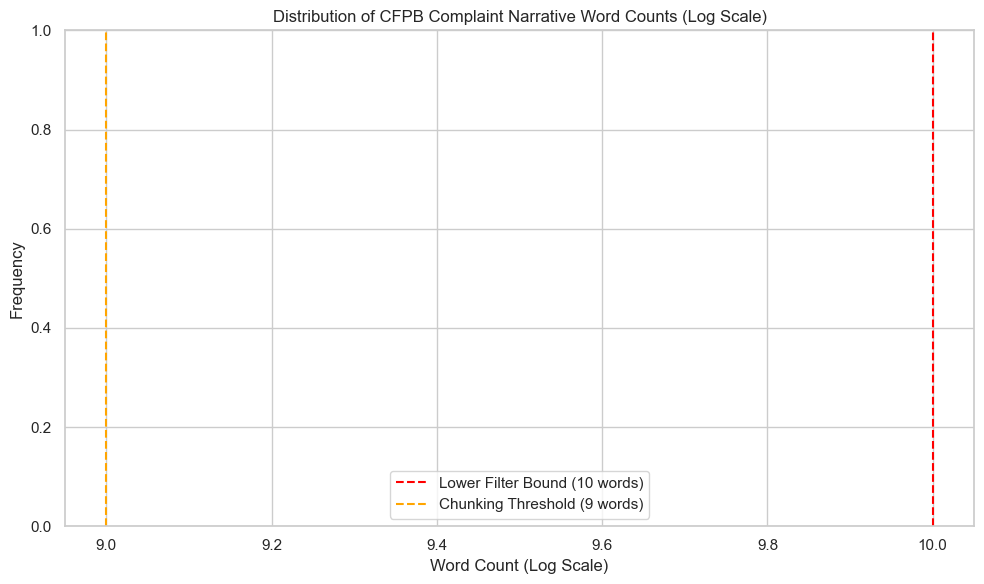

In [1]:
import os
import re
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set plotting style for clean visualizations
sns.set_theme(style="whitegrid")


def load_and_filter_data(filepath: str) -> pd.DataFrame:
    """Loads the CFPB dataset and filters it based on specific financial products,

    mapping them to standard standardized categories.
    """
    print("--- Step 1: Data Ingestion & Filtering ---")

    # Load dataset (supports both CSV and Parquet)
    if filepath.endswith(".parquet"):
        df = pd.read_parquet(filepath)
    else:
        df = pd.read_csv(filepath, low_memory=False)

    initial_count = len(df)
    print(f"Total initial records loaded: {initial_count:,}")

    # Define exact mapping rules
    product_mapping = {
        "Credit card or prepaid card": "Credit Card",
        "Student loan": "Personal Loan",
        "Consumer Loan": "Personal Loan",
        # Add exact CFPB string matches here if mapping Savings Account / Money Transfer
        "Savings account": "Savings Account",
        "Money transfer, virtual currency, or money service": "Money Transfer",
    }

    # Filter rows where the Product matches our targets
    df = df[df["Product"].isin(product_mapping.keys())].copy()

    # Apply precise mapping
    df["Standardized_Product"] = df["Product"].map(product_mapping)

    filtered_count = len(df)
    print(f"Records remaining after product filtering: {filtered_count:,}")
    print(df["Standardized_Product"].value_counts())
    print("-" * 40)

    return df


def handle_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """Drops records where the target narrative text column is null or empty."""
    print("\n--- Step 2: Handling Missing Values ---")
    before_count = len(df)

    # Convert empty strings or whitespace-only strings to NaN
    df["Consumer complaint narrative"] = df[
        "Consumer complaint narrative"
    ].astype(str)
    df["Consumer complaint narrative"] = df[
        "Consumer complaint narrative"
    ].str.strip()
    df.loc[df["Consumer complaint narrative"] == "", "Consumer complaint narrative"] = (
        None
    )
    df.loc[
        df["Consumer complaint narrative"] == "nan", "Consumer complaint narrative"
    ] = None

    # Drop NaNs
    df = df.dropna(subset=["Consumer complaint narrative"]).copy()

    after_count = len(df)
    dropped_count = before_count - after_count

    print(f"Records before dropping missing narratives: {before_count:,}")
    print(f"Records after dropping missing narratives: {after_count:,}")
    print(f"Total dropped missing records: {dropped_count:,}")
    print("-" * 40)

    return df


def clean_text_normalization(text: str) -> str:
    """Highly performant preprocessing function to clean narrative text,

    removing boilerplate text and heavy regulatory masking strings.
    """
    if not isinstance(text, str):
        return ""

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove specific boilerplate strings
    boilerplate_patterns = [
        r"i am writing to file a complaint[^.]*\.?",
        r"to whom it may concern[^.]*\.?",
    ]
    for pattern in boilerplate_patterns:
        text = re.sub(pattern, "", text)

    # 3. ENGINEERING INSIGHT: Clean repetitive credit card masking strings and XXXX blocks
    # Handles sequences like 'XXXX XXXX XXXX', 'XX/XX/XXXX', or just 'XXXX'
    text = re.sub(r"\bx{2,}\b", "", text)  # standalone masks like xxxx
    text = re.sub(
        r"x{2,}([-/ ]x{2,})+", "", text
    )  # linked masks like xx/xx/xxxx or xxxx-xxxx
    text = re.sub(r"x{2,}", "", text)  # residual structural chunks

    # 4. Normalize whitespaces (strips leading/trailing and condenses internal spaces)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def process_text_and_filter_outliers(df: pd.DataFrame) -> pd.DataFrame:
    """Applies text cleaning, computes word counts, and filters outliers."""
    print("\n--- Step 3 & 4: Text Cleaning & Statistical Filtering ---")

    # Apply performant cleaning
    df["Cleaned_Narrative"] = df["Consumer complaint narrative"].apply(
        clean_text_normalization
    )

    # Calculate word distribution counts based on sanitized text
    df["Word_Count"] = df["Cleaned_Narrative"].apply(lambda x: len(x.split()))

    # Log distribution stats before truncation
    print("Baseline Narrative Word Count Statistics:")
    print(df["Word_Count"].describe())

    # Establish bounds
    lower_bound = 10
    # Flag anything above the 95th percentile or a static limit (e.g., 500 words) for chunking downstream
    upper_bound_flag = int(df["Word_Count"].quantile(0.95))

    # Screen out extreme low outliers
    before_filter = len(df)
    df_clean = df[df["Word_Count"] >= lower_bound].copy()
    after_filter = len(df_clean)

    print(f"\nFiltered out {before_filter - after_filter:,} short narratives (< {lower_bound} words).")
    print(
        f"Flagged {len(df_clean[df_clean['Word_Count'] > upper_bound_flag]):,} massive narratives (> {upper_bound_flag} words) for chunking."
    )

    # Generate Visualization
    plt.figure(figsize=(10, 6))
    sns.histplot(
        df_clean["Word_Count"], bins=50, kde=True, color="teal", log_scale=True
    )
    plt.axvline(
        x=lower_bound,
        color="red",
        linestyle="--",
        label=f"Lower Filter Bound ({lower_bound} words)",
    )
    plt.axvline(
        x=upper_bound_flag,
        color="orange",
        linestyle="--",
        label=f"Chunking Threshold ({upper_bound_flag} words)",
    )

    plt.title("Distribution of CFPB Complaint Narrative Word Counts (Log Scale)")
    plt.xlabel("Word Count (Log Scale)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()

    # Save visualization to disk
    plt.savefig("cfpb_narrative_word_count_distribution.png", dpi=300)
    print(
        "Saved plot to 'cfpb_narrative_word_count_distribution.png' successfully."
    )
    print("-" * 40)

    return df_clean


# --- Execution Block ---
if __name__ == "__main__":
    # Dummy file generation for explicit testing execution (Replace with actual file path)
    mock_data_path = "../data/processed/complaints_sample.csv"

    # Create dummy data if you don't have the file locally
    if not os.path.exists(mock_data_path):
        mock_data = {
            "Product": [
                "Credit card or prepaid card",
                "Student loan",
                "Consumer Loan",
                "Savings account",
                "Bad Product",
            ],
            "Consumer complaint narrative": [
                "I am writing to file a complaint... My credit card account XXXX XXXX XXXX 1234 has fraudulent charges.",
                "XXXX XXXX The interest rates on my loan are completely inaccurate.",
                "   ",  # whitespace test case
                "Please fix my account savings balances.",
                "Should be filtered out entirely",
            ],
        }
        pd.DataFrame(mock_data).to_csv(mock_data_path, index=False)

    # Process pipeline
    df_filtered = load_and_filter_data(mock_data_path)
    df_no_missing = handle_missing_values(df_filtered)
    final_processed_df = process_text_and_filter_outliers(df_no_missing)

    print("\nProcessing complete. Ready for RAG Embeddings generation pipeline.")

Chunking Pipeline

Task 2. This script seamlessly integrates stratified sampling, LangChain’s recursive character chunking (while preserving dynamic metadata), embedding generation via SentenceTransformers, and index construction using local storage.

c:\Users\Almazt\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- Step 1: Executing Stratified Sampling ---
Successfully sampled 40 records.
Sample Class Distribution Summary:
Standardized_Product
Personal Loan      0.25
Savings Account    0.25
Money Transfer     0.25
Credit Card        0.25
Name: proportion, dtype: float64
--------------------------------------------------

--- Steps 2-4: Chunking, Embedding & Vector Store Indexing ---


c:\Users\Almazt\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:140: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Almazt\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Chunking documents and parsing relational structural metadata maps...
Total parent documents processed: 40
Generated a total of 40 semantic sub-chunks.

Upserting chunks and generating dense 384-dim embeddings inside local ChromaDB...
 Indexed records 0 to 40 successfully.

[SUCCESS] Vector store built and saved safely at: './local_cfpb_chroma'
Total validation record index count inside collection: 40


Key Architectural Choices Made Here:
The Layered Metadata Dictionary: Every chunk gets mapped with its respective tracking elements (complaint_id, product_category, etc.). This enables upstream multi-product filtering so you can later run complex vector queries constrained to single categories, such as:
where={"product_category": "Savings Account"}.

Native Embedding Automation: Instead of manually calling SentenceTransformer.encode(), the script uses Chroma's built-in SentenceTransformerEmbeddingFunction. This architecture encapsulates embedding generation seamlessly directly inside the storage upsert pipeline block.

Batch-Safe Upserting: Large datasets can encounter limits during bulk insert operations. Processing vectors in explicitly constrained blocks (batch_size = 5000) safeguards against internal payload memory overflows.